In [1]:
# ============================================
# Project 12 — Feature Engineering Performance Lab
# Business Question: Can better features beat a better model?
# Dataset: IBM Telco Customer Churn
# Approach: Same XGBoost — Raw features vs Engineered features
# Prajwal Kondala | IIT KGP → AI/ML Engineer
# ============================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

print("All imports done! ✅")

All imports done! ✅


In [4]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nFirst look:")
df.head()

Shape: (7043, 21)

First look:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# ============================================
# Preprocessing — same as Project 11!
# ============================================

# Drop customerID — not a feature!
df = df.drop('customerID', axis=1)

# Fix TotalCharges — hidden spaces!
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Encode all categoricals
df = pd.get_dummies(df, drop_first=True)

print("Shape after preprocessing:", df.shape)
print("Churn rate:", df['Churn'].mean().round(3))
print("\nAll columns:")
print(df.columns.tolist())

Shape after preprocessing: (7032, 31)
Churn rate: 0.266

All columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [6]:
# ============================================
# Train Test Split
# ============================================

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # same churn ratio in both!
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

X_train shape: (5625, 30)
X_test shape: (1407, 30)

Train churn rate: 0.266
Test churn rate: 0.266


In [7]:
# ============================================
# Baseline Model — SAME params as Project 11 tuned XGBoost!
# ============================================

# Class imbalance ratio — same calculation as before!
scale_pos = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
print("scale_pos_weight:", scale_pos)

baseline_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

baseline_model.fit(X_train, y_train)
print("\nBaseline model trained! ✅")

scale_pos_weight: 2.76

Baseline model trained! ✅


In [8]:
# ============================================
# Baseline Scores — OUR BENCHMARK!
# ============================================

baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)[:, 1]

baseline_recall    = recall_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred)
baseline_f1        = f1_score(y_test, baseline_pred)
baseline_auc       = roc_auc_score(y_test, baseline_prob)

print("=" * 40)
print("BASELINE SCORES — DO NOT CHANGE!")
print("=" * 40)
print(f"Recall    : {baseline_recall:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"F1        : {baseline_f1:.4f}")
print(f"AUC       : {baseline_auc:.4f}")
print("=" * 40)

BASELINE SCORES — DO NOT CHANGE!
Recall    : 0.8102
Precision : 0.4959
F1        : 0.6152
AUC       : 0.8409


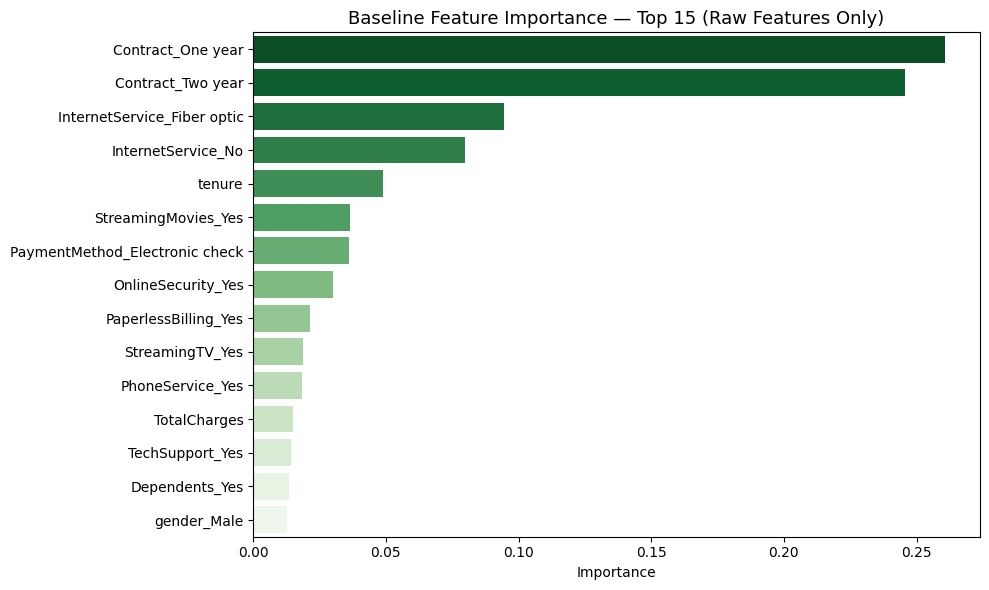


Top 5 baseline features:
                        Feature  Importance
24            Contract_One year    0.260887
25            Contract_Two year    0.245729
10  InternetService_Fiber optic    0.094343
11           InternetService_No    0.079657
1                        tenure    0.049025


In [9]:
# ============================================
# Baseline Feature Importance
# ============================================

importance_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Importance' : baseline_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Greens_r')
plt.title('Baseline Feature Importance — Top 15 (Raw Features Only)', fontsize=13)
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.savefig('baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 baseline features:")
print(importance_df.head())

In [12]:
# ============================================
# Baseline Summary
# ============================================
print("Dataset  : IBM Telco Churn — 7032 rows, 30 features")
print("Model    : XGBoost — learning_rate=0.05, max_depth=3")
print()
print("Recall    :", 0.8102)
print("Precision :", 0.4959)
print("F1        :", 0.6152)
print("AUC       :", 0.8409)
print()
print("Target: Beat Recall 0.8102 with engineered features!")

Dataset  : IBM Telco Churn — 7032 rows, 30 features
Model    : XGBoost — learning_rate=0.05, max_depth=3

Recall    : 0.8102
Precision : 0.4959
F1        : 0.6152
AUC       : 0.8409

Target: Beat Recall 0.8102 with engineered features!
